In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline


In [4]:
df = pd.read_csv('ai_financial_market_daily_realistic_synthetic.csv')
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


In [30]:
#show basic info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [31]:
#convert datatype of date column into datetime format

df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                233 non-null    object        
 6   Stock_Impact_%       10959 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 599.4+ KB


In [32]:
#ccreate new column for year

df['Year'] = df['Date'].dt.year
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015
...,...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66,2024
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57,2024
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52,2024
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22,2024


1) How much amount the companies spent on R & D ?

In [12]:
print("Companies spending for R & D in $Bn")

RD = df.groupby('Company')['R&D_Spending_USD_Mn'].sum()/1000
RD

Companies spending for R & D in $Bn


Company
Google    423.34114
Meta      264.53307
OpenAI     26.48277
Name: R&D_Spending_USD_Mn, dtype: float64

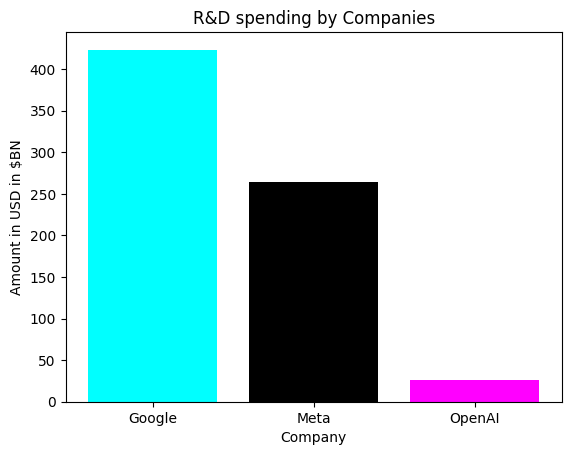

In [13]:
#draw bar plot to show amount spent on R&D BY companies

plt.bar(RD.index, RD.values, color = ['cyan', 'black', 'magenta'])

plt.title("R&D spending by Companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD in $BN")
plt.show()

2 REVENUE EARNED BY THE COMPANIES

In [16]:
rev = df.groupby("Company")["AI_Revenue_USD_Mn"].sum()/1000   #BY DIVIDING 1000 CONVERTING IT INTO BILLIONS
rev

Company
Google    284.49838
Meta      189.62182
OpenAI      9.46289
Name: AI_Revenue_USD_Mn, dtype: float64

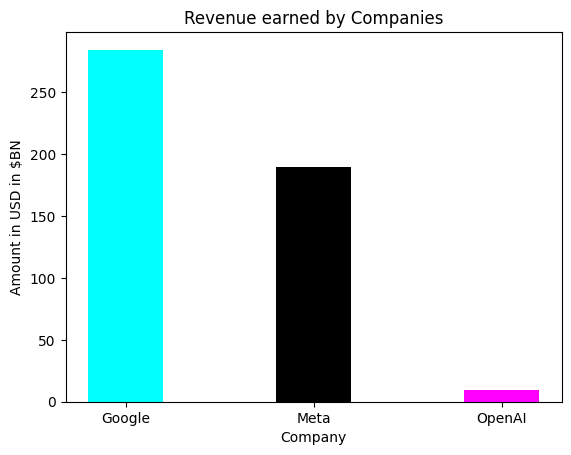

In [17]:
#draw bar plot to show revenue earned BY companies
plt.bar(rev.index, rev.values, color = ['cyan', 'black', 'magenta'], width=0.4)

plt.title("Revenue earned by Companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD in $BN")
plt.show()

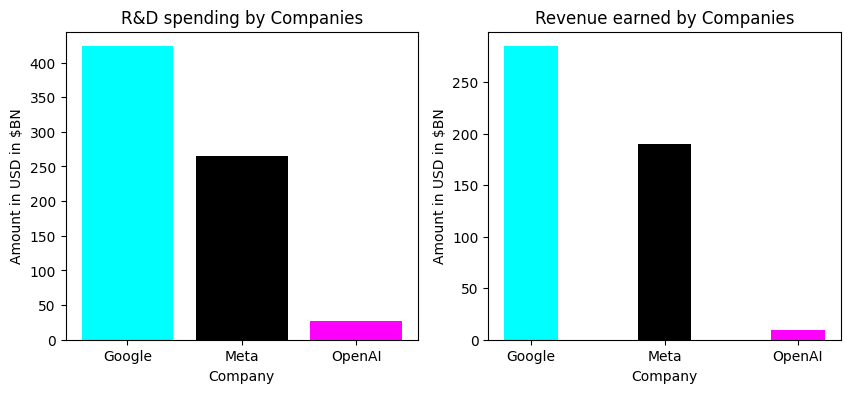

In [18]:
#bar plot to show expenditure and revenue of companies

plt.figure(figsize= (10,4))

plt.subplot(1, 2, 1)

plt.bar(RD.index, RD.values, color = ['cyan', 'black', 'magenta'])

plt.title("R&D spending by Companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD in $BN")

plt.subplot(1, 2, 2)

plt.bar(rev.index, rev.values, color = ['cyan', 'black', 'magenta'], width=0.4)

plt.title("Revenue earned by Companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD in $BN")

plt.show()

3 Date-wise Impact on the Stock

        Date  Stock_Impact_%
0 2015-01-01       -0.266667
1 2015-01-02        0.020000
2 2015-01-03        0.580000
3 2015-01-04        0.086667
4 2015-01-05       -0.413333


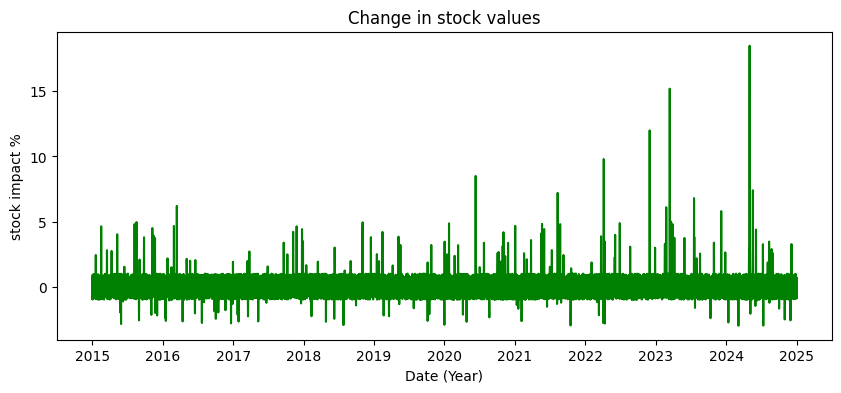

In [24]:
date_wise_impact = (
    df.groupby("Date")["Stock_Impact_%"]
      .mean()
      .reset_index()
)
print(date_wise_impact.head(5))

plt.figure(figsize= (10,4))
plt.plot(df['Date'], df['Stock_Impact_%'], color = 'green')
plt.title("Change in stock values")
plt.xlabel("Date (Year)")
plt.ylabel("stock impact %")
plt.show()

4 Create separate dataframes

In [11]:
data_openAI = df[df['Company'] == 'OpenAI']
data_openAI

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,NaN,0.93
3649,2024-12-28,OpenAI,9.67,5.32,432.15,NaN,-0.25
3650,2024-12-29,OpenAI,9.17,5.46,445.74,NaN,0.47
3651,2024-12-30,OpenAI,10.36,6.31,530.88,NaN,0.69


In [6]:
data_google = df[df['Company'] == 'Google']
data_meta = df[df['Company'] == 'Meta']

In [7]:
data_google

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
3653,2015-01-01,Google,79.89,30.19,0.64,NaN,-0.02
3654,2015-01-02,Google,78.99,30.44,1.47,NaN,-0.98
3655,2015-01-03,Google,79.20,30.46,1.53,NaN,0.78
3656,2015-01-04,Google,79.59,30.55,1.82,NaN,-0.41
3657,2015-01-05,Google,81.50,30.59,1.97,NaN,-0.78
...,...,...,...,...,...,...,...
7301,2024-12-27,Google,162.16,155.36,417.88,NaN,-0.46
7302,2024-12-28,Google,159.69,154.47,414.89,NaN,-0.48
7303,2024-12-29,Google,161.69,154.59,415.31,NaN,0.72
7304,2024-12-30,Google,158.48,155.05,416.84,NaN,-0.17


In [8]:
data_meta

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
7306,2015-01-01,Meta,50.39,18.95,-5.23,NaN,-0.42
7307,2015-01-02,Meta,49.80,19.77,-1.16,NaN,0.63
7308,2015-01-03,Meta,49.09,19.96,-0.21,NaN,0.73
7309,2015-01-04,Meta,50.66,20.48,2.38,NaN,-0.26
7310,2015-01-05,Meta,51.36,19.84,-0.80,NaN,-0.37
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


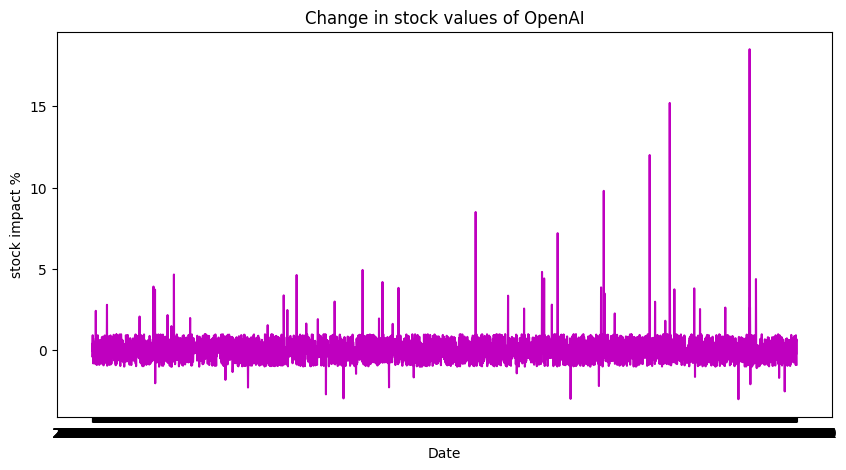

In [12]:
plt.figure(figsize= (10,5))
plt.plot(data_openAI['Date'], data_openAI['Stock_Impact_%'], color = 'm')

plt.title("Change in stock values of OpenAI")
plt.xlabel("Date")
plt.ylabel("stock impact %")
plt.show()

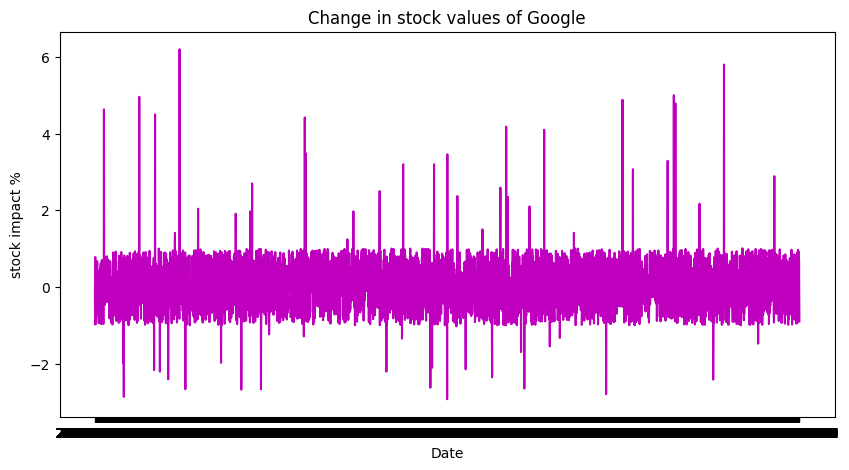

In [15]:
plt.figure(figsize= (10,5))

plt.plot(data_google['Date'], data_google['Stock_Impact_%'], color = 'm')

plt.title("Change in stock values of Google")
plt.xlabel("Date")
plt.ylabel("stock impact %")
plt.show()

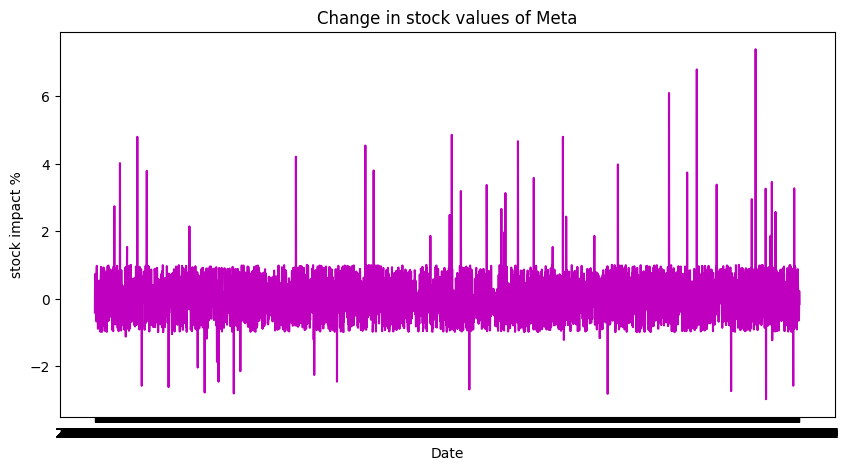

In [14]:
plt.figure(figsize= (10,5))

plt.plot(data_meta['Date'], data_meta['Stock_Impact_%'], color = 'm')

plt.title("Change in stock values of Meta")
plt.xlabel("Date")
plt.ylabel("stock impact %")

plt.show()

5. Events when Maximum Stock Impact was Observed

In [ ]:
#OPENAI EVENTS

data_openAI.sort_values( by = 'Stock_Impact_%', ascending=False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
3408,2024-05-01,OpenAI,10.91,5.34,434.27,GPT-5 release (predicted),18.50
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.20
2890,2022-11-30,OpenAI,10.60,3.18,217.72,ChatGPT (GPT-3.5) launch,12.00
2652,2022-04-06,OpenAI,9.24,3.48,247.93,DALL·E 2 release,9.80
1988,2020-06-11,OpenAI,5.90,2.62,161.56,GPT-3 release,8.50
...,...,...,...,...,...,...,...
3590,2024-10-30,OpenAI,11.05,5.27,427.50,AI-powered search update,-2.52
1212,2018-04-27,OpenAI,5.38,1.76,76.47,AI ethics policy update,-2.70
1303,2018-07-27,OpenAI,7.44,0.97,-2.63,AI-powered search update,-2.95
2480,2021-10-16,OpenAI,8.39,2.78,178.28,AI Ads Optimization upgrade,-2.98


In [ ]:
#GOOGLES EVENTS

data_google.sort_values( by = 'Stock_Impact_%', ascending=False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
4092,2016-03-15,Google,84.56,36.22,20.73,AlphaGo beats Lee Sedol,6.20
6914,2023-12-06,Google,146.59,129.17,330.55,Gemini AI release,5.80
6654,2023-03-21,Google,149.34,129.76,332.53,Bard chatbot launch,5.00
3883,2015-08-19,Google,79.27,30.89,2.98,AI partnership deal,4.96
6388,2022-06-28,Google,137.71,107.96,259.85,AI ethics policy update,4.88
...,...,...,...,...,...,...,...
4122,2016-04-14,Google,87.19,36.08,20.28,AI partnership deal,-2.67
4412,2017-01-29,Google,92.21,43.25,44.17,AI Ads Optimization upgrade,-2.68
6303,2022-04-04,Google,138.00,106.81,256.04,AI Video Recommendation upgrade,-2.80
3803,2015-05-31,Google,81.14,29.30,-2.32,Cloud AI launch,-2.87


In [18]:
#META EVENTS

data_meta.sort_values( by = 'Stock_Impact_%', ascending=False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
10731,2024-05-18,Meta,103.64,103.05,415.23,LLaMA 3 release (predicted),7.40
10426,2023-07-18,Meta,92.44,85.67,328.37,LLaMA 2 release,6.80
10282,2023-02-24,Meta,93.71,86.98,334.89,LLaMA 1 release,6.10
9156,2020-01-25,Meta,72.73,49.10,145.49,Cloud AI launch,4.86
7526,2015-08-09,Meta,48.97,19.95,-0.27,AI Video Recommendation upgrade,4.80
...,...,...,...,...,...,...,...
10604,2024-01-12,Meta,99.37,104.28,421.42,AI Video Recommendation upgrade,-2.75
7875,2016-07-23,Meta,53.76,23.97,19.83,AI-powered search update,-2.79
8026,2016-12-21,Meta,53.18,23.42,17.11,AI-powered search update,-2.82
9964,2022-04-12,Meta,84.90,71.99,259.95,AI ethics policy update,-2.83


6. AI Revenue Growth of Companies

In [19]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


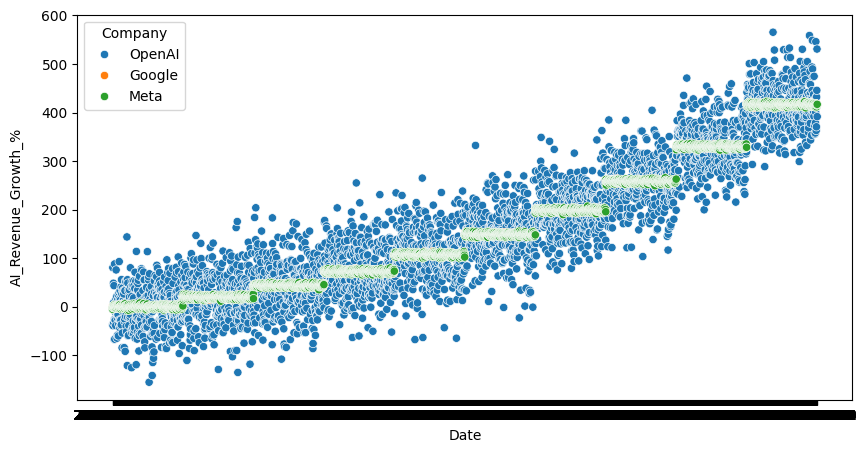

In [20]:
plt.figure(figsize= (10, 5))

sns.scatterplot(x= 'Date', y='AI_Revenue_Growth_%', data = df ,hue='Company')
plt.show()

In [21]:
df.sort_values(by= ['AI_Revenue_Growth_%'])

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
189,2015-07-09,OpenAI,5.66,-0.55,-155.43,NaN,0.70
205,2015-07-25,OpenAI,5.23,-0.42,-141.61,NaN,-0.62
649,2016-10-11,OpenAI,5.37,-0.35,-135.31,NaN,0.12
548,2016-07-02,OpenAI,5.19,-0.29,-129.11,NaN,-0.31
98,2015-04-09,OpenAI,4.80,-0.25,-125.50,NaN,-0.56
...,...,...,...,...,...,...,...
3508,2024-08-09,OpenAI,9.92,6.33,532.86,NaN,0.77
3645,2024-12-24,OpenAI,8.79,6.46,546.07,NaN,0.45
3627,2024-12-06,OpenAI,8.51,6.49,548.83,NaN,-0.15
3612,2024-11-21,OpenAI,10.16,6.59,558.70,NaN,0.63


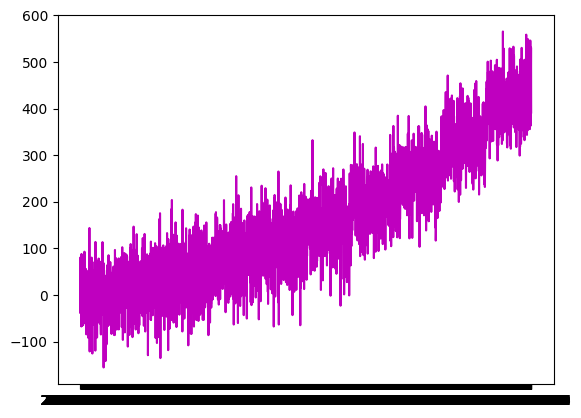

In [23]:
#OPENAI REVENUE GROWTH YEAR BY YEAR

plt.plot( data_openAI['Date'], data_openAI['AI_Revenue_Growth_%'], color = 'm')
plt.show()

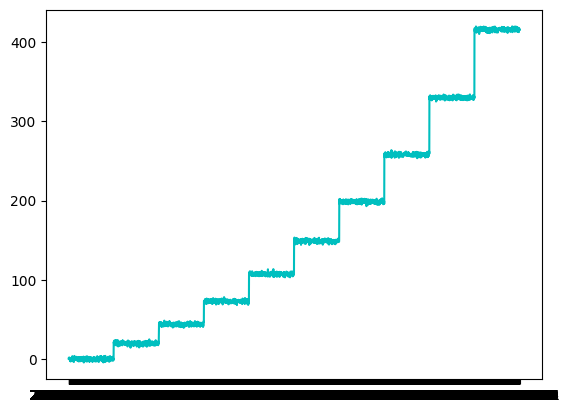

In [24]:
#Google REVENUE GROWTH YEAR BY YEAR

plt.plot( data_google['Date'], data_google['AI_Revenue_Growth_%'], color = 'c')
plt.show()

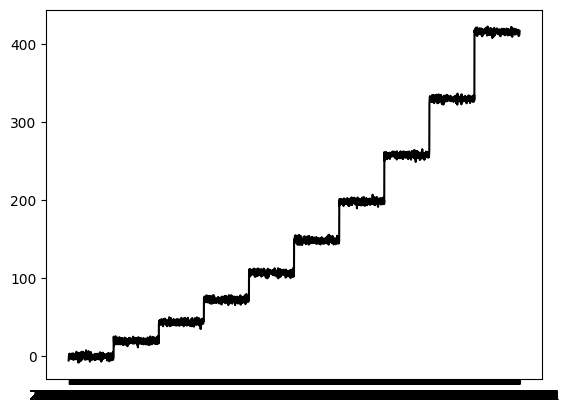

In [25]:
#meta REVENUE GROWTH YEAR BY YEAR

plt.plot( data_meta['Date'], data_meta['AI_Revenue_Growth_%'], color = 'black')
plt.show()

7. Correlation Between Columns

<Axes: >

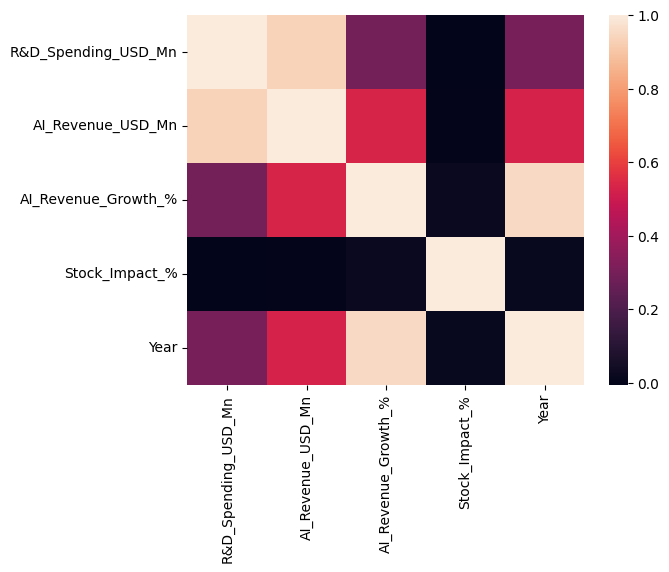

In [33]:
sns.heatmap( df.corr(numeric_only = True))

8. Expenditure vs Revenue Year-by-Year

In [34]:
spend = df.groupby('Year')['R&D_Spending_USD_Mn'].sum()
spend

Year
2015    49304.23
2016    53349.94
2017    57475.12
2018    62002.16
2019    67071.51
2020    72602.53
2021    78207.32
2022    84390.17
2023    91193.92
2024    98760.08
Name: R&D_Spending_USD_Mn, dtype: float64

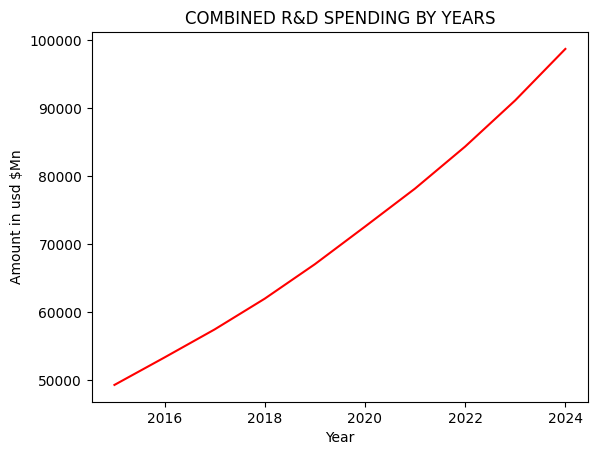

In [36]:
#showing the amount spend on R & D

plt.plot(spend.index, spend.values, color = 'r')
plt.title("COMBINED R&D SPENDING BY YEARS")
plt.xlabel("Year")
plt.ylabel("Amount in usd $Mn")
plt.show()

In [37]:

revenue =df.groupby('Year')['AI_Revenue_USD_Mn'].sum()
revenue 

Year
2015    18623.21
2016    22361.20
2017    26776.80
2018    32164.44
2019    38580.32
2020    46456.19
2021    55591.14
2022    66674.24
2023    80041.64
2024    96313.91
Name: AI_Revenue_USD_Mn, dtype: float64

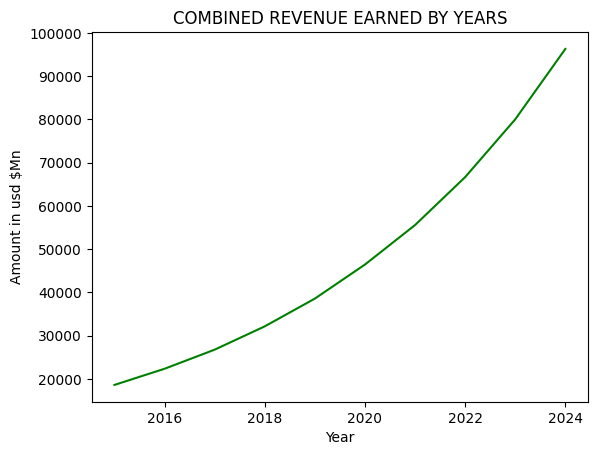

In [38]:
#showing the revenue earned

plt.plot(revenue.index, revenue.values, color = 'g')
plt.title("COMBINED REVENUE EARNED BY YEARS")
plt.xlabel("Year")
plt.ylabel("Amount in usd $Mn")
plt.show()

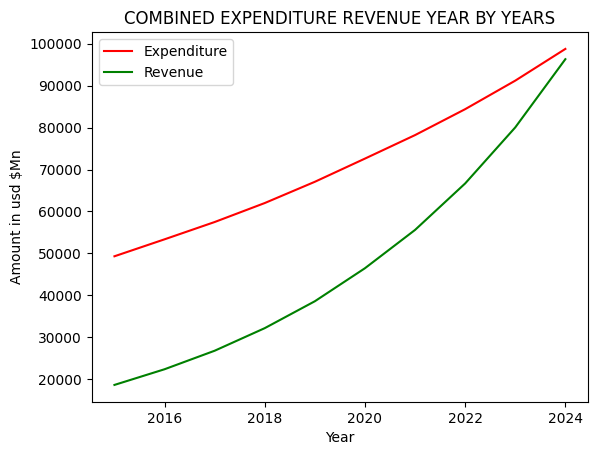

In [42]:
plt.plot(spend.index, spend.values, color = 'r')
plt.plot(revenue.index, revenue.values, color = 'g')

plt.title("COMBINED EXPENDITURE REVENUE YEAR BY YEARS", fontsize = 12)
plt.xlabel("Year")
plt.ylabel("Amount in usd $Mn")

plt.legend(['Expenditure','Revenue'])

plt.show()

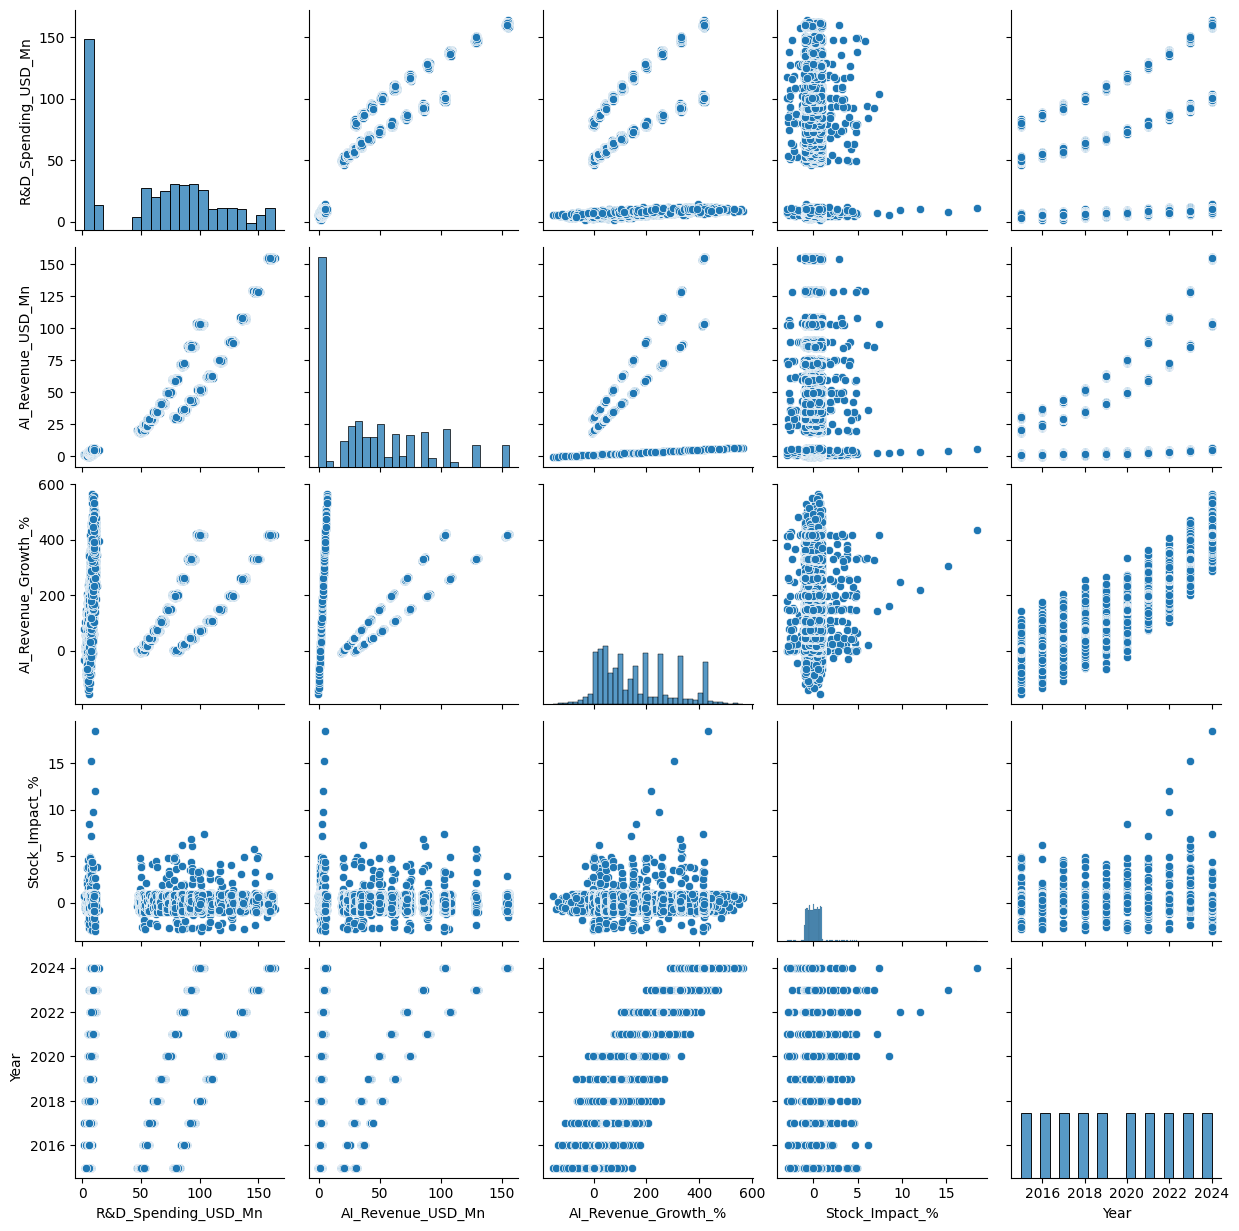

In [43]:
#pairplot to show the relation between the columns

sns.pairplot(df);

9 Event impact Analysis

In [44]:
df.Event.value_counts()

Event
AI speech recognition release      37
AI Ads Optimization upgrade        32
AI partnership deal                32
AI-powered search update           32
AI Video Recommendation upgrade    29
AI ethics policy update            27
Cloud AI launch                    27
GPT-1 release                       1
GPT-2 release                       1
GPT-3 release                       1
Codex release                       1
DALL·E 2 release                    1
ChatGPT (GPT-3.5) launch            1
GPT-4 release                       1
GPT-5 release (predicted)           1
TensorFlow open-source release      1
AlphaGo beats Lee Sedol             1
BERT for Search launch              1
MUM Search Model launch             1
Bard chatbot launch                 1
Gemini AI release                   1
LLaMA 1 release                     1
LLaMA 2 release                     1
LLaMA 3 release (predicted)         1
Name: count, dtype: int64

In [45]:
#checking for particular event

df[df.Event == 'ChatGPT (GPT-3.5) launch']

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
2890,2022-11-30,OpenAI,10.6,3.18,217.72,ChatGPT (GPT-3.5) launch,12.0,2022


In [47]:
tf = df.loc[ 2870 : 2900 ]
tf

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
2870,2022-11-10,OpenAI,9.19,3.93,292.98,NaN,0.25,2022
2871,2022-11-11,OpenAI,7.88,3.47,246.67,NaN,0.56,2022
2872,2022-11-12,OpenAI,11.22,3.77,276.59,NaN,-0.01,2022
2873,2022-11-13,OpenAI,6.46,3.52,252.14,NaN,0.85,2022
2874,2022-11-14,OpenAI,6.83,3.39,238.66,NaN,0.13,2022
2875,2022-11-15,OpenAI,8.95,2.45,145.04,NaN,0.27,2022
2876,2022-11-16,OpenAI,8.40,3.17,216.70,NaN,0.68,2022
2877,2022-11-17,OpenAI,7.95,3.40,240.28,NaN,-0.95,2022
2878,2022-11-18,OpenAI,7.23,3.90,289.54,NaN,-0.43,2022
2879,2022-11-19,OpenAI,7.68,2.17,116.78,NaN,-0.11,2022


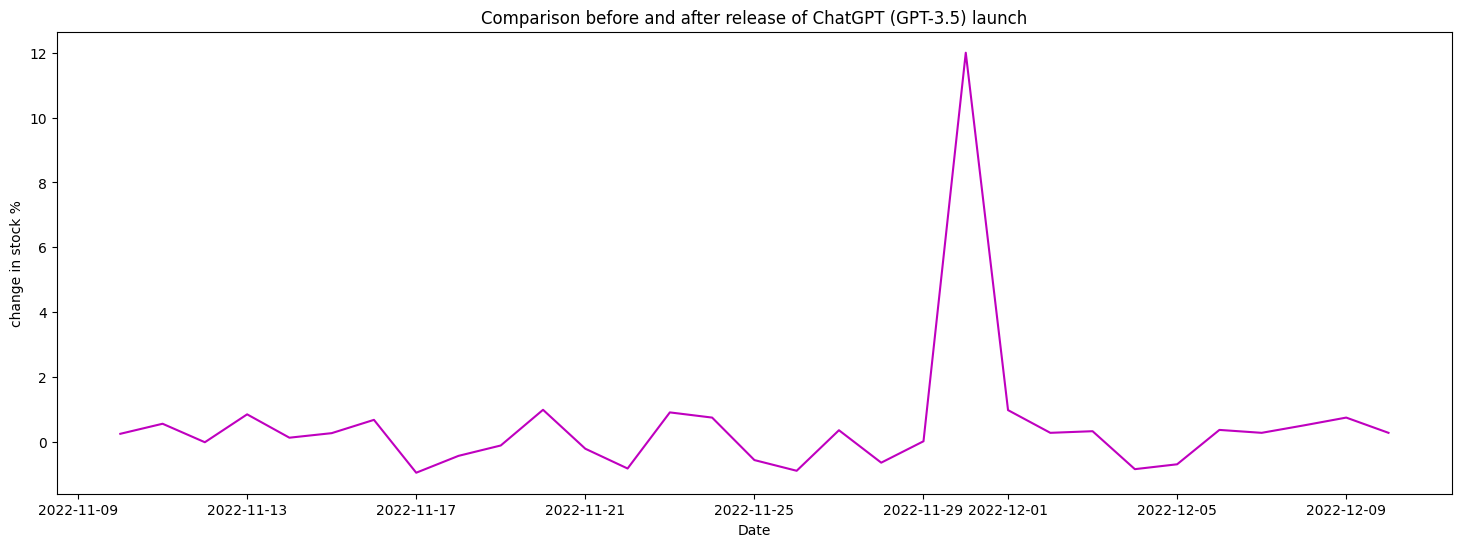

In [52]:
#showing impact with the line chart

plt.figure(figsize= (18,6))

plt.plot(tf['Date'], tf['Stock_Impact_%'], color = 'm')

plt.title("Comparison before and after release of ChatGPT (GPT-3.5) launch")
plt.xlabel("Date")
plt.ylabel("change in stock %")

plt.show()

In [54]:
#daily average impact on the stock of compoanies

df.groupby('Company')['Stock_Impact_%'].mean()*100

Company
Google    2.620860
Meta      0.976184
OpenAI    4.070901
Name: Stock_Impact_%, dtype: float64

In [55]:
#DAILY AVERAGE EXPENDITURE ON R & D BY THE COMPANIES

df.groupby('Company')['R&D_Spending_USD_Mn'].mean()

Company
Google    115.888623
Meta       72.415294
OpenAI      7.249595
Name: R&D_Spending_USD_Mn, dtype: float64

In [56]:
#maximum stock impact % on a company

df.groupby('Company')['Stock_Impact_%'].max()

Company
Google     6.2
Meta       7.4
OpenAI    18.5
Name: Stock_Impact_%, dtype: float64

10. Change in Index w.r.t Year & Company

In [58]:
stocks = df.groupby(['Year','Company'])['Stock_Impact_%'].max() 
stocks

Year  Company
2015  Google      4.96
      Meta        4.80
      OpenAI      3.92
2016  Google      6.20
      Meta        2.14
      OpenAI      4.66
2017  Google      4.42
      Meta        4.21
      OpenAI      4.63
2018  Google      1.97
      Meta        4.54
      OpenAI      4.94
2019  Google      3.20
      Meta        1.86
      OpenAI      4.20
2020  Google      4.18
      Meta        4.86
      OpenAI      8.50
2021  Google      4.10
      Meta        4.80
      OpenAI      7.20
2022  Google      4.88
      Meta        3.98
      OpenAI     12.00
2023  Google      5.80
      Meta        6.80
      OpenAI     15.20
2024  Google      2.89
      Meta        7.40
      OpenAI     18.50
Name: Stock_Impact_%, dtype: float64

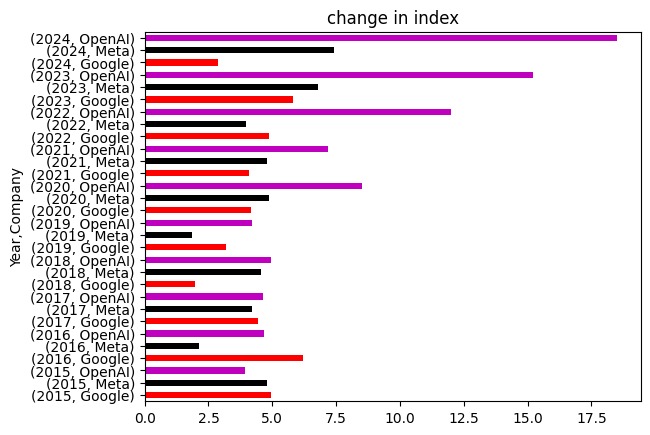

In [60]:
stocks.plot(kind= 'barh', color = [ 'r', 'black', 'm'])
plt.title("change in index")
plt.show()